#**1. DataSet**

In [ ]:
from google.colab import files

# Ini akan membuka dialog untuk mengunggah file.
# Anda dapat memilih satu atau lebih file.
uploaded = files.upload()

# Untuk melihat nama file yang diunggah dan ukurannya:
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

In [ ]:
import pandas as pd

attrition_df = pd.read_csv('Attrition.csv', sep=';')
print(attrition_df.head())

   Age Attrition BusinessTravel  DailyRate              Department  \
0   58       Yes  Travel_Rarely        147  Research & Development   
1   55        No     Non-Travel        177  Research & Development   
2   56        No  Travel_Rarely       1369  Research & Development   
3   52        No     Non-Travel        771                   Sales   
4   50        No  Travel_Rarely       1099  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                23          4        Medical              1             165   
1                 8          1        Medical              1            1278   
2                23          3  Life Sciences              1            1373   
3                 2          4  Life Sciences              1             329   
4                29          4  Life Sciences              1             569   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...                        

#**2. Eksplorasi Data**

**a. Statistika Deskriptif**

In [ ]:
attrition_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
attrition_df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


**Interpretasi:**
- Dataset terdiri dari 1.470 karyawan
- Kelas target tidak seimbang, di mana 83,88% karyawan bertahan dan 16,12% keluar.
- Mayoritas karyawan bekerja pada departemen Research & Development
- Rata-rata usia karyawan adalah 36,92 tahun dengan pengalaman kerja sekitar 11 tahun.
- Variabel EmployeeCount, StandardHours, dan Over18 bersifat konstan sehingga dapat dieliminasi sebelum pemodelan.

**b. Vusialisasi**

deklarasi variabel kategorik

In [ ]:
# List of variables to be treated as categorical
categorical_vars_to_declare = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'Over18', 'MaritalStatus', 'OverTime',
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance'
]

# Convert specified columns to 'category' dtype
for col in categorical_vars_to_declare:
    if col in attrition_df.columns:
        attrition_df[col] = attrition_df[col].astype('category')

print("Updated dtypes for declared categorical variables:")
display(attrition_df[categorical_vars_to_declare].dtypes)

# Display the first few rows to see the effect of type conversion (if any)
print("\nFirst 5 rows of the DataFrame with updated categorical types:")
display(attrition_df.head())

Updated dtypes for declared categorical variables:


,0
Attrition,category
BusinessTravel,category
Department,category
EducationField,category
Gender,category
JobRole,category
Over18,category
MaritalStatus,category
OverTime,category
Education,category



First 5 rows of the DataFrame with updated categorical types:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,58,Yes,Travel_Rarely,147,Research & Development,23,4,Medical,1,165,...,4,80,1,40,3,2,40,10,15,6
1,55,No,Non-Travel,177,Research & Development,8,1,Medical,1,1278,...,4,80,1,34,3,3,33,9,15,0
2,56,No,Travel_Rarely,1369,Research & Development,23,3,Life Sciences,1,1373,...,1,80,1,33,0,3,19,16,15,9
3,52,No,Non-Travel,771,Sales,2,4,Life Sciences,1,329,...,4,80,0,33,2,4,33,7,15,12
4,50,No,Travel_Rarely,1099,Research & Development,29,4,Life Sciences,1,569,...,2,80,1,28,2,3,27,10,15,7


deklarasi variabel numerik

In [ ]:
import numpy as np

# Get all columns that are currently numerical (int64, float64)
current_numerical_cols = attrition_df.select_dtypes(include=np.number).columns.tolist()

# Get all columns that are currently categorical
current_categorical_cols = attrition_df.select_dtypes(include='category').columns.tolist()

# Identify numerical columns that are NOT in the current categorical list
# This ensures we only get purely numerical columns for further analysis
purely_numerical_vars = [col for col in current_numerical_cols if col not in current_categorical_cols]

print("Purely Numerical Variables (not declared as categorical):")
for col in purely_numerical_vars:
    print(f"- {col}")

print("\nData types of purely numerical variables:")
display(attrition_df[purely_numerical_vars].dtypes)

Purely Numerical Variables (not declared as categorical):
- Age
- DailyRate
- DistanceFromHome
- EmployeeCount
- EmployeeNumber
- HourlyRate
- MonthlyIncome
- MonthlyRate
- NumCompaniesWorked
- PercentSalaryHike
- StandardHours
- TotalWorkingYears
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager

Data types of purely numerical variables:


,0
Age,int64
DailyRate,int64
DistanceFromHome,int64
EmployeeCount,int64
EmployeeNumber,int64
HourlyRate,int64
MonthlyIncome,int64
MonthlyRate,int64
NumCompaniesWorked,int64
PercentSalaryHike,int64


**visualisasi variabel kategorik**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# Get the list of all currently declared categorical columns
categorical_cols_for_viz = attrition_df.select_dtypes(include='category').columns.tolist()

print("--- Visualizations for Categorical Variables ---")

# --- Pie Charts and Histograms (Bar Charts) for individual categorical variables ---
for col in categorical_cols_for_viz:
    num_unique = attrition_df[col].nunique()

    # Skip 'Over18' if it has only one unique value 'Y' as it's not informative
    if col == 'Over18' and num_unique == 1:
        print(f"Skipping '{col}' as it has only one unique value: {attrition_df[col].iloc[0]}")
        continue

    plt.figure(figsize=(8, 6))
    if num_unique <= 7: # Use pie chart for variables with few unique categories
        attrition_df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', wedgeprops=dict(width=0.3))
        plt.title(f'Distribution of {col} (Pie Chart)', fontsize=14)
        plt.ylabel('') # Hide the default label
    else: # Use histplot for variables with more unique categories, resembling a histogram for counts
        # Using histplot for categorical data will effectively create bins for each category and show counts
        sns.histplot(x=col, data=attrition_df, palette='viridis', hue=col, legend=False, shrink=0.8)
        plt.title(f'Distribution of {col} (Histogram)', fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- Heatmap for Categorical vs. Categorical Variables (Cramer's V) ---
print("\n--- Heatmap of Association (Cramer's V) between Categorical Variables ---")

# Function to calculate Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    # Handle cases where phi2 might be close to 1 due to small counts, leading to division by zero
    if min(k-1, r-1) == 0:
        return 1.0 # Perfect association if one variable has only one category
    v = np.sqrt(phi2 / min(k-1, r-1))
    return v

# Create a matrix to store Cramer's V values
cramers_v_matrix = pd.DataFrame(index=categorical_cols_for_viz, columns=categorical_cols_for_viz)

for col1 in categorical_cols_for_viz:
    for col2 in categorical_cols_for_viz:
        if col1 == 'Over18' and attrition_df[col1].nunique() == 1: # Skip 'Over18' if it has only one value
            cramers_v_matrix.loc[col1, col2] = 0 # No variance, so no association
            continue
        if col2 == 'Over18' and attrition_df[col2].nunique() == 1: # Skip 'Over18' if it has only one value
            cramers_v_matrix.loc[col1, col2] = 0 # No variance, so no association
            continue

        cramers_v_matrix.loc[col1, col2] = cramers_v(attrition_df[col1], attrition_df[col2])

# Convert the matrix to float type for heatmap plotting
cramers_v_matrix = cramers_v_matrix.astype(float)

plt.figure(figsize=(16, 14)) # Adjust figure size for better readability
sns.heatmap(cramers_v_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title("Cramer's V Association Heatmap for Categorical Variables", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**visualisasi variabel numerik**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Visualizations for Numerical Variables ---")

# Get the list of purely numerical columns
numerical_cols_for_viz = purely_numerical_vars

# Exclude 'EmployeeCount' and 'StandardHours' if they are present and have zero variance
# based on the describe() output, these columns have a standard deviation of 0, making them uninformative for distribution plots.
numerical_cols_for_viz = [col for col in numerical_cols_for_viz if attrition_df[col].std() > 0]

# --- Histograms for individual numerical variables ---
print("\n--- Histograms for Numerical Variables ---")
for col in numerical_cols_for_viz:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=attrition_df, x=col, kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col} (Histogram)', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.show()

# --- Boxplots for individual numerical variables ---
print("\n--- Boxplots for Numerical Variables ---")
for col in numerical_cols_for_viz:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=attrition_df, y=col, color='lightcoral')
    plt.title(f'Boxplot of {col}', fontsize=15)
    plt.ylabel(col, fontsize=12)
    plt.tight_layout()
    plt.show()

# --- Heatmap for Numerical vs. Numerical Variables (Correlation) ---
print("\n--- Heatmap of Numerical Variable Correlations ---")

# Calculate the correlation matrix for numerical variables
df_corr = attrition_df.drop(columns=['EmployeeNumber'])
# Filter numerical_cols_for_viz to exclude 'EmployeeNumber' for correlation heatmap
cols_for_corr_heatmap = [col for col in numerical_cols_for_viz if col != 'EmployeeNumber']
correlation_matrix_numerical = df_corr[cols_for_corr_heatmap].corr()

plt.figure(figsize=(18, 16)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix_numerical, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title("Correlation Heatmap for Numerical Variables", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretasi :**
- Variabel MonthlyRate memiliki distribusi yang relatif merata di seluruh rentang nilainya. Artinya, jumlah karyawan pada berbagai tingkat MonthlyRate cenderung seimbang dan tidak terpusat pada kelompok tertentu. Distribusi ini menunjukkan bahwa MonthlyRate memiliki variasi yang cukup tinggi antar karyawan.
- Distribusi YearsSinceLastPromotion menunjukkan bahwa mayoritas karyawan memiliki rentang waktu yang relatif singkat sejak promosi terakhir, dengan konsentrasi terbesar pada 0–2 tahun. Namun, terdapat sebagian kecil karyawan yang telah lama tidak mendapatkan promosi, hingga mencapai 15 tahun. Distribusi yang condong ke kanan ini mengindikasikan bahwa sebagian besar karyawan masih berada pada fase karier yang relatif aktif dalam memperoleh promosi.
- Distribusi MonthlyIncome menunjukkan bahwa sebagian besar karyawan memperoleh pendapatan bulanan pada tingkat rendah hingga menengah, sementara hanya sebagian kecil yang menerima pendapatan tinggi. Distribusi yang menceng ke kanan mengindikasikan adanya ketimpangan pendapatan antar karyawan, di mana kelompok berpenghasilan tinggi jumlahnya jauh lebih sedikit dibandingkan kelompok berpenghasilan rendah dan menengah.


**Interpretasi**

- terdapat bebrapa variabel yang memiliki ouliner salah satu nya montly income, namun ouliner ini masih masuk dalam akal karena semakin tinggi jabatan akan semakin tinggi pemasukan perbulannya,
- variabel YearsAtCompany terdapat outliner sehingga sitribusi untuk variabel tersebut tidak merata.

**Heatmap**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Re-using the lists from previous cells
categorical_cols = categorical_cols_for_viz
# Filter out 'EmployeeNumber' from numerical_cols_for_viz for this heatmap
numerical_cols = [col for col in numerical_cols_for_viz if col != 'EmployeeNumber']

# Create an empty DataFrame to store the Eta-squared values
eta_squared_matrix = pd.DataFrame(index=numerical_cols, columns=categorical_cols, dtype=float)

# Function to calculate Eta-squared manually for one-way ANOVA
def calculate_eta_squared(data, numerical_col, categorical_col):
    groups = data.groupby(categorical_col)[numerical_col]
    group_means = groups.mean()
    group_counts = groups.count()
    grand_mean = data[numerical_col].mean()

    ss_between = sum(group_counts[g] * (group_means[g] - grand_mean)**2 for g in group_means.index)
    ss_total = ((data[numerical_col] - grand_mean)**2).sum()

    if ss_total == 0:
        return 0.0 # No variance in numerical_col, so no explained variance
    return ss_between / ss_total

# Populate the eta_squared_matrix
for num_col in numerical_cols:
    for cat_col in categorical_cols:
        # Skip 'Over18' if it has only one unique value 'Y' as it's not informative
        if cat_col == 'Over18' and attrition_df[cat_col].nunique() == 1:
            eta_squared_matrix.loc[num_col, cat_col] = 0.0
            continue

        # Ensure there's enough data for ANOVA (at least 2 groups and observations within groups)
        # and that the numerical column is not entirely NaN (though info() shows no nulls)
        if attrition_df[cat_col].nunique() < 2 or attrition_df[num_col].isnull().all():
             eta_squared_matrix.loc[num_col, cat_col] = 0.0 # Cannot compute eta-squared
             continue

        eta_squared_matrix.loc[num_col, cat_col] = calculate_eta_squared(attrition_df, num_col, cat_col)

# Plot the heatmap
plt.figure(figsize=(18, 14)) # Adjust size as needed
sns.heatmap(eta_squared_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, linecolor='black')
plt.title("Heatmap of Eta-squared (Categorical vs. Numerical Variables)", fontsize=16)
plt.xlabel("Categorical Variables", fontsize=12)
plt.ylabel("Numerical Variables", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**c. Identifikasi**

**1. cek missing value**

In [ ]:
attrition_df.isnull().sum()

Interpretasi

dalam dataset ini tidak terdapat missing value.

**2. Cek Duplikasi Data**

In [ ]:
duplicate_rows = attrition_df.duplicated().sum()

if duplicate_rows == 0:
    print("Tidak ditemukan duplikasi data dalam dataset.")
else:
    print(f"Ditemukan {duplicate_rows} baris data yang terduplikasi dalam dataset.")
    # Optionally, to view the duplicate rows:
    # display(attrition_df[attrition_df.duplicated(keep=False)])

In [ ]:
duplicate_employee_numbers = attrition_df[attrition_df['EmployeeNumber'].duplicated(keep=False)]

if not duplicate_employee_numbers.empty:
    print(f"Ditemukan duplikasi data pada variabel 'EmployeeNumber'. Jumlah baris yang terduplikasi adalah {len(duplicate_employee_numbers)}.")
    print("Berikut adalah EmployeeNumber yang terduplikasi:")
    display(duplicate_employee_numbers['EmployeeNumber'].value_counts().reset_index(name='count'))
else:
    print("Tidak ditemukan duplikasi data pada variabel 'EmployeeNumber'. Setiap karyawan memiliki EmployeeNumber yang uniK.")

**interpretasi**

dalam data set ini tidak terdapat duplikasi data.

**3. Ouliner**

berdasarkan hasil boxplot sudah teridentifikasi terdapat beberapa variable yang mengalami outliner yaitu, NumCopmenisWorked terdapat 1 nilai variabel, Total WorkingYears terdapat lebih dari 5 ouliner,YearsAtCpmpany terdapat lebih dari 5 ouliner, YearsInCurrentRole terdapat 4 ouliner, YearsSinceLastPromotion terdapat lebih dari 5 ouliner, YearsWithCurrManager terdapat 3 ouliner, sehingga diperlukan penanganan.

**4. Ketidakseimbangan kelas**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the frequency of the 'Attrition' variable
attrition_counts = attrition_df['Attrition'].value_counts()

print("Frequency of Attrition variable:")
print(attrition_counts)

# Visualize the frequency using a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='viridis')
plt.title('Frequency Distribution of Attrition', fontsize=15)
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

**Interpretasi**

berdasarkan visualisasi diatas bahwa adanya ketidakseimbangan kelas untuk variabel terget yaitu attrition sehingga diperlukan penanganan.

## **3. Preprocessing Data &Rekayasa Fitur**

**a. penanganan missing value**

dalam dataset ini sudah melakukan validasi tidak adanya missing value dalam data

**penanganan ouliner**



Berikut adalah ringkasan dari penanganan outlier:

NumCompaniesWorked: 232 outlier terdeteksi dan dihapus.
YearsInCurrentRole: 18 outlier terdeteksi dan dihapus.
YearsWithCurrManager: 37 outlier terdeteksi dan dihapus.
Jumlah baris asli adalah 1470, dan setelah penghapusan outlier, tersisa 1183 baris. Total 287 baris telah dihapus.

In [ ]:
import numpy as np

# List of variables for outlier treatment based on user's request
outlier_cols = [
    'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

original_rows = attrition_df.shape[0]
print(f"Original number of rows: {original_rows}")

# Loop through each column to identify and remove outliers using the IQR method
for col in outlier_cols:
    Q1 = attrition_df[col].quantile(0.25)
    Q3 = attrition_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = attrition_df[(attrition_df[col] < lower_bound) | (attrition_df[col] > upper_bound)]

    if not outliers.empty:
        print(f"\nOutliers detected in '{col}':")
        print(f"  Number of outliers: {outliers.shape[0]}")
        # Remove outliers
        attrition_df = attrition_df[~((attrition_df[col] < lower_bound) | (attrition_df[col] > upper_bound))]
        print(f"  Removed {outliers.shape[0]} rows for outliers in '{col}'.")
    else:
        print(f"\nNo outliers detected in '{col}'.")


# Report the final number of rows after outlier removal
final_rows = attrition_df.shape[0]
removed_rows = original_rows - final_rows

print(f"\nFinal number of rows after outlier treatment: {final_rows}")
print(f"Total rows removed due to outliers: {removed_rows}")

print("\nFirst 5 rows of the DataFrame after outlier treatment:")
display(attrition_df.head())

data outliner sudah berhasil ditangani dengan IQR

**b Encoding**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Make a copy to avoid modifying the original DataFrame directly for preprocessing
df_encoded = attrition_df.copy()

# 1. Encode the target variable 'Attrition' (Yes=1, No=0)
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

# 2. Identify and drop uninformative columns and unique identifiers
# Based on previous analysis, 'EmployeeCount', 'StandardHours', 'Over18' have no variance.
# 'EmployeeNumber' is a unique identifier and should not be used as a feature.
uninformative_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_encoded = df_encoded.drop(columns=[col for col in uninformative_cols if col in df_encoded.columns])

# 3. Separate features (X) and target (y)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# 4. Identify categorical columns for encoding
# These lists are based on the previous context where we declared categorical_vars_to_declare
# and identified numerical columns.

ordinal_cols = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance'
]

nominal_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime'
]

# Combine all categorical columns that need label encoding
# The user requested 'label encoding only, not one-hot'
all_categorical_cols_for_label_encoding = ordinal_cols + nominal_cols

# Ensure all identified columns actually exist in X after dropping uninformative ones
all_categorical_cols_for_label_encoding = [col for col in all_categorical_cols_for_label_encoding if col in X.columns]

# Define the order for ordinal features if known, otherwise OrdinalEncoder assigns based on sorted unique values
# For simplicity, if explicit order is not specified for all, we will let OrdinalEncoder sort them.
# If specific orders are needed, they would be defined here, e.g., categories=[['Low', 'Medium', 'High', 'Very High']]

# Create preprocessing pipeline for all categorical features using OrdinalEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_label_enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), all_categorical_cols_for_label_encoding) # Assign -1 for unknown during transform
    ],
    remainder='passthrough' # Keep numerical columns as they are
)

# Apply the transformations
X_encoded = preprocessor.fit_transform(X)

# Get the feature names after encoding
# This part can be tricky because ColumnTransformer returns a NumPy array.
# To get a DataFrame back with meaningful column names, we need to extract them.

# The names of the features that were label encoded are simply the original column names
label_encoded_feature_names = all_categorical_cols_for_label_encoding

# Get names for numerical features (remainder)
# We need to find columns that were not touched by the transformer
all_transformed_cols = all_categorical_cols_for_label_encoding
remainder_cols = [col for col in X.columns if col not in all_transformed_cols]

# Combine all feature names
new_column_names = label_encoded_feature_names + remainder_cols

X_encoded_df = pd.DataFrame(X_encoded, columns=new_column_names, index=X.index)

print("Shape of original features (X):", X.shape)
print("Shape of encoded features (X_encoded_df):", X_encoded_df.shape)
print("\nFirst 5 rows of encoded features (X_encoded_df):")
display(X_encoded_df.head())

print("\nData types of encoded features:")
display(X_encoded_df.info())

print("\nFirst 5 rows of target variable (y):")
display(y.head())

interpretasi

data ini sudah dilakukan encoding untuk data kategorik sehingga semua untuk jenis data kategori menjjadi numerik

**c. Scalling Data / Normalisasi**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Identify numerical columns that were passed through (these are the original numerical columns)
# We can reuse 'remainder_cols' from the previous cell, which contains the list of numerical columns
# that were not transformed by OrdinalEncoder or OneHotEncoder.
# However, it's safer to re-derive it from X_encoded_df's dtypes if we are not directly running the previous cell.

# Let's get the list of columns that are still 'numerical' in the traditional sense (not one-hot encoded categories)
# These are the ones that were in 'remainder_cols' from the previous step and the ordinal encoded ones.
# The current X_encoded_df has all columns as float64, so we need to be careful.

# The 'remainder_cols' from the previous step correctly identified the original numerical features
# that simply passed through the ColumnTransformer.
# We will apply MinMaxScaler only to these columns.

numerical_features_to_scale = remainder_cols # This list comes from the previous cell HVIO2CfAk9A6

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply the scaler to the selected numerical features in X_encoded_df
X_encoded_df[numerical_features_to_scale] = scaler.fit_transform(X_encoded_df[numerical_features_to_scale])

print("Fitur numerik telah berhasil dinormalisasi (0-1).")
print("\nFirst 5 rows of normalized features (X_encoded_df):")
display(X_encoded_df.head())

print("\nStatistics of normalized numerical features:")
display(X_encoded_df[numerical_features_to_scale].describe())

standarisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify columns to standardize (ordinal and original numerical columns)
# Re-using the lists from previous cells: ordinal_feature_names and remainder_cols
# These lists should contain the column names that were either ordinal encoded or were original numerical features.

features_to_standardize = ordinal_feature_names + remainder_cols

# Initialize the StandardScaler
scaler_standard = StandardScaler()

# Apply the scaler to the selected features in X_encoded_df
# It's important to do this on a copy if X_encoded_df is needed in its Min-Max scaled form elsewhere.
# For this step, we'll directly modify X_encoded_df as the user requested 'standardisasi for the data'.
X_encoded_df[features_to_standardize] = scaler_standard.fit_transform(X_encoded_df[features_to_standardize])

print("Fitur numerik dan ordinal telah berhasil distandarisasi (mean=0, std=1).")
print("\nFirst 5 rows of standardized features (X_encoded_df):")
display(X_encoded_df.head())

print("\nStatistics of standardized features:")
display(X_encoded_df[features_to_standardize].describe())

**d. Featur Engginering**

menentukan variabel target

In [24]:
# X is already defined as X_encoded_df from previous preprocessing steps
# y is already defined as the encoded 'Attrition' column

# We will just confirm the shapes and show head to ensure clarity

print("Shape of Independent Variables (X):", X_encoded_df.shape)
print("Shape of Dependent Variable (y):", y.shape)

print("\nFirst 5 rows of Independent Variables (X):")
display(X_encoded_df.head())

print("\nFirst 5 rows of Dependent Variable (y):")
display(y.head())

Shape of Independent Variables (X): (1119, 30)
Shape of Dependent Variable (y): (1119,)

First 5 rows of Independent Variables (X):


,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TrainingTimesLastYear,WorkLifeBalance,...,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
217,3.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,6.0,1.0,...,0.528571,0.501901,0.719019,0.750,0.071429,0.892857,0.500000,0.500000,1.0,0.363636
219,2.0,2.0,2.0,3.0,1.0,0.0,3.0,1.0,2.0,3.0,...,0.300000,0.823756,0.372781,1.000,0.071429,0.821429,0.722222,0.857143,1.0,0.090909
224,2.0,3.0,2.0,0.0,3.0,0.0,1.0,0.0,3.0,2.0,...,0.171429,0.058413,0.553530,0.125,0.071429,0.607143,0.944444,0.857143,1.0,0.636364
225,3.0,3.0,1.0,1.0,2.0,0.0,2.0,1.0,1.0,3.0,...,0.242857,0.258424,0.501687,0.500,0.214286,0.607143,0.833333,0.785714,1.0,0.818182
228,3.0,3.0,2.0,1.0,1.0,0.0,0.0,2.0,3.0,2.0,...,0.800000,0.181208,0.222432,0.000,0.285714,0.571429,0.833333,0.928571,1.0,0.727273



First 5 rows of Dependent Variable (y):


,Attrition
217,0
219,0
224,0
225,0
228,0


data sudah dibagi menjadi variabel dependen dengan variabel Attrition dan untuk variabel independen semua variabel

**e. Pembagian Data**

In [25]:
from sklearn.model_selection import train_test_split

# Split the preprocessed data (before PCA) into training and testing sets
# X_encoded_df is the feature set after encoding and scaling, but before PCA
# y is the target variable

X_train, X_test, y_train, y_test = train_test_split(X_encoded_df, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train (before PCA):", X_train.shape)
print("Shape of X_test (before PCA):", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in y_train:")
display(y_train.value_counts(normalize=True))

print("\nClass distribution in y_test:")
display(y_test.value_counts(normalize=True))

Shape of X_train (before PCA): (895, 30)
Shape of X_test (before PCA): (224, 30)
Shape of y_train: (895,)
Shape of y_test: (224,)

Class distribution in y_train:


,proportion
Attrition,
0,0.832402
1,0.167598



Class distribution in y_test:


,proportion
Attrition,
0,0.830357
1,0.169643


telah dilakukan pembagian data dengan data training testing dengan proporsi 80:20

##**4. Pemodelan**

**a. Balance data**

In [26]:
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE # Import SMOTE
from collections import Counter

print("Class distribution before SMOTE:", Counter(y_train))

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data. This process balances the 'Attrition' variable (y_train).
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:", Counter(y_train_resampled))

print("\nShape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)

print("\nFirst 5 rows of X_train_resampled:")
display(X_train_resampled.head())

print("\nFirst 5 rows of y_train_resampled:")
display(y_train_resampled.head())

Class distribution before SMOTE: Counter({0: 745, 1: 150})

Class distribution after SMOTE: Counter({1: 745, 0: 745})

Shape of X_train_resampled: (1490, 30)
Shape of y_train_resampled: (1490,)

First 5 rows of X_train_resampled:


,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TrainingTimesLastYear,WorkLifeBalance,...,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1.0,5.0,2.0,...,0.871429,0.159607,0.293109,0.625,0.142857,0.214286,0.111111,0.142857,0.0,0.181818
1,1.0,1.0,3.0,0.0,2.0,0.0,2.0,0.0,3.0,2.0,...,0.185714,0.125013,0.673279,0.125,0.142857,0.357143,0.555556,0.428571,0.0,0.727273
2,3.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,...,0.285714,0.018485,0.564493,0.125,0.071429,0.035714,0.055556,0.000000,0.0,0.000000
3,2.0,1.0,2.0,1.0,1.0,0.0,2.0,1.0,3.0,3.0,...,0.528571,0.054558,0.921452,0.500,0.071429,0.607143,0.166667,0.142857,0.2,0.181818
4,2.0,3.0,1.0,4.0,3.0,0.0,2.0,0.0,3.0,3.0,...,0.657143,0.911376,0.266485,0.750,0.071429,0.892857,0.055556,0.000000,0.0,0.000000



First 5 rows of y_train_resampled:


,Attrition
0,1
1,0
2,1
3,0
4,0


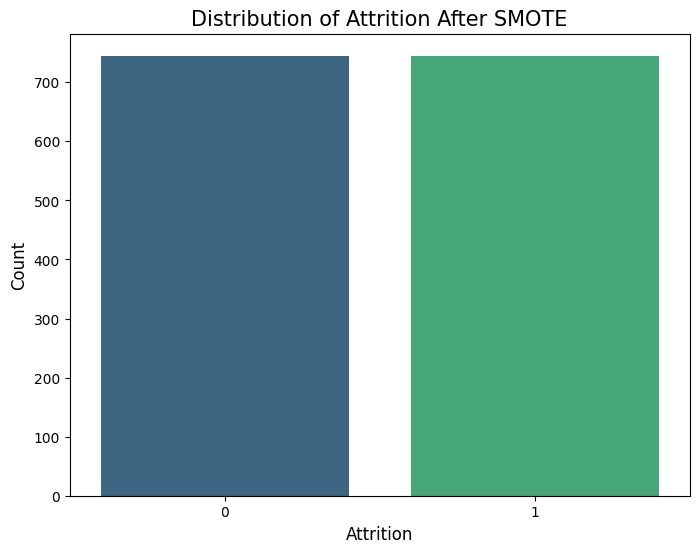

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_resampled, hue=y_train_resampled, palette='viridis', legend=False)
plt.title('Distribution of Attrition After SMOTE', fontsize=15)
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

setelah dilakukan penanganan keseimbangan data untuk variabel target yaitu attretion, maka variabel tersebut telah balance atau seimbang sehingga dapat dilakukan pemodelan

**b. Pemodelan**

1. Logistik regresion

--- Logistic Regression Model Evaluation ---
Accuracy: 0.8036
Precision: 0.4559
Recall: 0.8158
F1-Score: 0.5849

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87       186
           1       0.46      0.82      0.58        38

    accuracy                           0.80       224
   macro avg       0.71      0.81      0.73       224
weighted avg       0.87      0.80      0.82       224



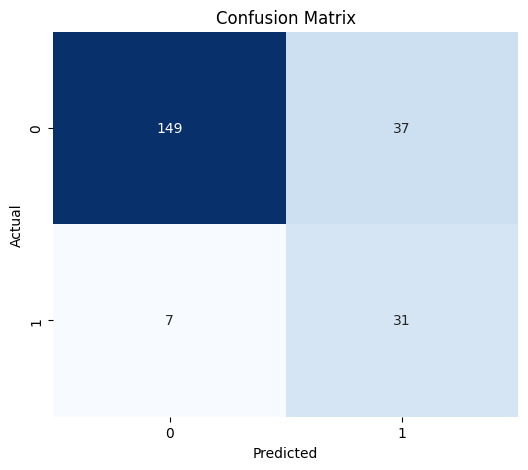

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets and handles L1/L2 regularization
log_reg_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print("--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

2. random forest

--- Random Forest Model Evaluation ---
Accuracy: 0.8705
Precision: 0.8000
Recall: 0.3158
F1-Score: 0.4528

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       186
           1       0.80      0.32      0.45        38

    accuracy                           0.87       224
   macro avg       0.84      0.65      0.69       224
weighted avg       0.86      0.87      0.85       224



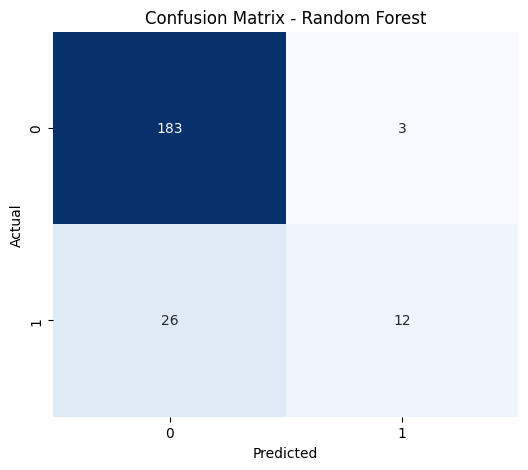

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Random Forest model
# Using class_weight='balanced' is often beneficial for imbalanced datasets, even after SMOTE.
# Alternatively, if SMOTE has perfectly balanced, default weights can be used.
# For now, let's keep it simple and rely on SMOTE for balancing.
rf_model = RandomForestClassifier(random_state=42, n_estimators=100) # n_estimators is number of trees
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("--- Random Forest Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

3. XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:21:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Model Evaluation ---
Accuracy: 0.8661
Precision: 0.6429
Recall: 0.4737
F1-Score: 0.5455

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       186
           1       0.64      0.47      0.55        38

    accuracy                           0.87       224
   macro avg       0.77      0.71      0.73       224
weighted avg       0.85      0.87      0.86       224



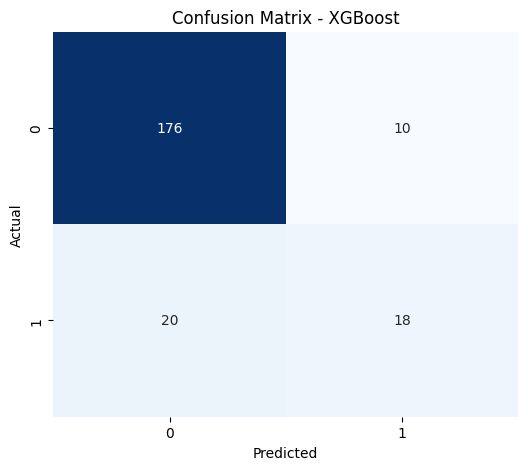

In [30]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the XGBoost model
# Using use_label_encoder=False and eval_metric for newer versions of XGBoost
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=100 # Number of boosting rounds/trees
)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("--- XGBoost Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Interpretasi Metrik Evaluasi Model

Untuk membandingkan ketiga model (Logistic Regression, Random Forest, dan XGBoost), kita akan fokus pada metrik `Precision`, `Recall`, dan `F1-Score` untuk kelas minoritas (Attrition = 1), karena dataset sebelumnya mengalami ketidakseimbangan kelas dan telah ditangani dengan SMOTE.

#### 1. Logistic Regression

*   **Accuracy:** 0.8036
*   **Precision (Class 1 - Attrition 'Yes'):** 0.4559
*   **Recall (Class 1 - Attrition 'Yes'):** 0.8158
*   **F1-Score (Class 1 - Attrition 'Yes'):** 0.5849

**Interpretasi:**
Model Regresi Logistik memiliki `Recall` tertinggi, yang berarti model ini sangat baik dalam mengidentifikasi sebagian besar karyawan yang benar-benar akan keluar (81.58% dari semua kasus positif teridentifikasi). Namun, `Precision`-nya cukup rendah, yang mengindikasikan bahwa banyak prediksi 'Yes' (akan keluar) adalah salah (false positives). Artinya, model ini cenderung memprediksi lebih banyak karyawan akan keluar daripada yang sebenarnya, sehingga berpotensi mengakibatkan intervensi yang tidak perlu.

#### 2. Random Forest

*   **Accuracy:** 0.8705
*   **Precision (Class 1 - Attrition 'Yes'):** 0.8000
*   **Recall (Class 1 - Attrition 'Yes'):** 0.3158
*   **F1-Score (Class 1 - Attrition 'Yes'):** 0.4528

**Interpretasi:**
Model Random Forest memiliki `Accuracy` tertinggi dan `Precision` yang sangat baik. Ini berarti ketika model memprediksi seorang karyawan akan keluar, prediksinya sangat mungkin benar (80% benar). Namun, `Recall`-nya sangat rendah, yang menunjukkan bahwa model ini melewatkan sebagian besar karyawan yang sebenarnya akan keluar. Ini adalah model yang sangat konservatif dalam memprediksi Attrition; ia hanya memprediksi positif jika sangat yakin, tetapi pada akhirnya gagal mengidentifikasi banyak kasus positif yang sebenarnya.

#### 3. XGBoost

*   **Accuracy:** 0.8661
*   **Precision (Class 1 - Attrition 'Yes'):** 0.6429
*   **Recall (Class 1 - Attrition 'Yes'):** 0.4737
*   **F1-Score (Class 1 - Attrition 'Yes'):** 0.5455

**Interpretasi:**
Model XGBoost menawarkan keseimbangan yang lebih baik antara `Precision` dan `Recall` dibandingkan kedua model lainnya. `Precision`-nya jauh lebih tinggi daripada Logistic Regression, yang berarti lebih sedikit prediksi palsu positif. `Recall`-nya juga lebih baik daripada Random Forest, yang berarti model ini mengidentifikasi lebih banyak kasus Attrition yang sebenarnya. `F1-Score`-nya juga cukup kompetitif.

### Kesimpulan dan Rekomendasi Model Terbaik

Pilihan model terbaik sangat tergantung pada tujuan bisnis. Dalam kasus prediksi Attrition, umumnya penting untuk mengidentifikasi sebanyak mungkin karyawan yang berisiko keluar (`Recall` tinggi) agar intervensi dapat dilakukan, sembari tetap menjaga tingkat `Precision` yang wajar untuk menghindari pemborosan sumber daya pada intervensi yang tidak perlu.

*   Jika prioritas utama adalah **meminimalkan False Negatives** (tidak melewatkan karyawan yang sebenarnya akan keluar), **Logistic Regression** mungkin pilihan yang lebih baik karena `Recall`-nya yang sangat tinggi, meskipun harus siap dengan banyak False Positives.
*   Jika prioritas utama adalah **meminimalkan False Positives** (tidak mengintervensi karyawan yang tidak berisiko), **Random Forest** adalah pilihan terbaik karena `Precision`-nya yang sangat tinggi, tetapi akan melewatkan banyak karyawan yang sebenarnya akan keluar.
*   **XGBoost** memberikan **keseimbangan yang paling optimal** antara `Precision` dan `Recall`. Model ini mampu mengidentifikasi sejumlah kasus Attrition yang signifikan (Recall 0.4737) sambil mempertahankan tingkat kebenaran prediksi yang baik (Precision 0.6429). Ini menjadikannya pilihan yang lebih **kuat dan seimbang** untuk skenario di mana biaya False Positives dan False Negatives sama-sama penting.

**Rekomendasi:** Berdasarkan analisis ini, **XGBoost** direkomendasikan sebagai model terbaik karena menawarkan kinerja yang paling seimbang dan robust dalam memprediksi Attrition.

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV completed.

Best Parameters found for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best F1-Score from cross-validation for Logistic Regression: 0.7979

--- Tuned Logistic Regression Model Evaluation on Test Set ---
Accuracy: 0.8036
Precision: 0.4559
Recall: 0.8158
F1-Score: 0.5849

Classification Report for Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87       186
           1       0.46      0.82      0.58        38

    accuracy                           0.80       224
   macro avg       0.71      0.81      0.73       224
weighted avg       0.87      0.80      0.82       224



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


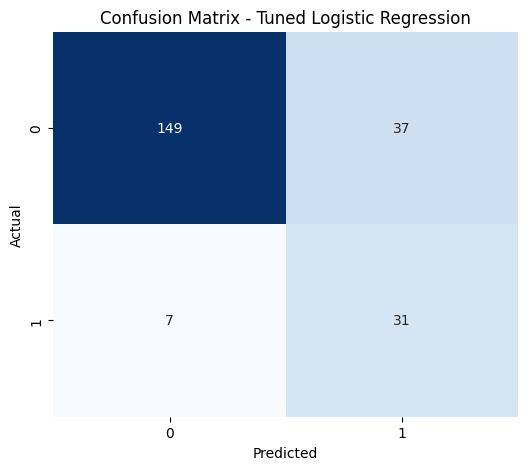

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'], # 'liblinear' works well for small datasets and L1/L2, 'saga' for larger and all penalties
    'penalty': ['l1', 'l2'] # L1 and L2 regularization
}

# Initialize the Logistic Regression model
lr_base_model = LogisticRegression(random_state=42)

# Initialize GridSearchCV
# We'll use 'f1' as the scoring metric since it's good for imbalanced datasets
# cv=5 for 5-fold cross-validation
# n_jobs=-1 to use all available CPU cores
grid_search_lr = GridSearchCV(
    estimator=lr_base_model,
    param_grid=param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Logistic Regression...")

# Fit GridSearchCV to the resampled training data
grid_search_lr.fit(X_train_resampled, y_train_resampled)

print("GridSearchCV completed.")

# Get the best parameters and best score
best_params_lr = grid_search_lr.best_params_
best_score_lr = grid_search_lr.best_score_

print(f"\nBest Parameters found for Logistic Regression: {best_params_lr}")
print(f"Best F1-Score from cross-validation for Logistic Regression: {best_score_lr:.4f}")

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_lr = best_lr_model.predict(X_test)

# Evaluate the best tuned model
print("\n--- Tuned Logistic Regression Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned_lr):.4f}")

print("\nClassification Report for Tuned Logistic Regression:")
print(classification_report(y_test, y_pred_tuned_lr))

# Confusion Matrix for the best tuned model
cm_tuned_lr = confusion_matrix(y_test, y_pred_tuned_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()